<a href="https://colab.research.google.com/github/ggg2929/MagiskOnWSALocal/blob/main/Data_Instagram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**normalisasi**

In [1]:
# ===================== 🔧 INSTALASI LIBRARY =====================
!pip install -q fasttext Sastrawi pandas tqdm

# ===================== 📦 DOWNLOAD fastText Bahasa Indonesia =====================
!wget -q https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.id.300.bin.gz
!gzip -d cc.id.300.bin.gz  # Hasil = cc.id.300.bin

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 1.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 917.0 kB/s eta 0:00:00


In [2]:
# ===================== 🔧 INSTALL (jalankan jika perlu) =====================
# !pip install fasttext pandas tqdm

# ===================== 📚 IMPORT LIBRARY =====================
import pandas as pd
import re
import fasttext
from tqdm import tqdm

# ===================== 📦 LOAD MODEL fastText =====================
print("📦 Memuat model fastText Bahasa Indonesia...")
ft_model = fasttext.load_model("cc.id.300.bin")  # Pastikan file ini tersedia

# ===================== 📁 BACA DATA KOMENTAR =====================
print("📁 Membaca file komentar...")
df = pd.read_csv("Data4.csv")  # Ganti jika nama file beda
df['text'] = df['text'].astype(str)

# ===================== 📌 FRASA PENTING (mapping sebelum proses per kata) =====================
frasa_khusus = {
    "ra mudeng": "tidak paham",
    "ora mudeng": "tidak paham",
    "ora ngerti": "tidak paham",
    "gak ngerti": "tidak paham",
    "nggak ngerti": "tidak paham",
    "gak mudeng": "tidak paham",
    "tidak ngerti": "tidak paham",
    "ngerti": "paham",
    "ngeh": "paham",
    "mudeng": "paham"
}

# ===================== 💡 CACHING UNTUK KATA UNIK =====================
cache_kata = {}

def normalisasi_otomatis_aman(word, threshold=0.75):
    word = word.lower()
    if word in cache_kata:
        return cache_kata[word]

    try:
        tetangga = ft_model.get_nearest_neighbors(word)
        for sim, near_word in tetangga:
            if sim >= threshold and near_word != word:
                cache_kata[word] = near_word
                return near_word
    except:
        pass
    cache_kata[word] = word
    return word

# ===================== 🔁 PRE-PROSES: BUAT KAMUS DARI SEMUA KATA UNIK =====================
print("🔍 Mengumpulkan semua kata unik...")
kata_unik = set()
for teks in df['text']:
    teks_bersih = teks.lower()
    for frasa, ganti in frasa_khusus.items():
        teks_bersih = teks_bersih.replace(frasa, ganti)
    tokens = re.sub(r'[^\w\s]', '', teks_bersih).split()
    kata_unik.update(tokens)

print(f"📊 Ditemukan {len(kata_unik)} kata unik. Memproses normalisasi dengan fastText...")

# Buat kamus normalisasi dari semua kata unik
normalisasi_dict = {}
for kata in tqdm(kata_unik, desc="⚙️ Normalisasi kata unik"):
    normalisasi_dict[kata] = normalisasi_otomatis_aman(kata)

# ===================== 🔁 PROSES NORMALISASI KOMENTAR MENGGUNAKAN KAMUS =====================
def normalisasi_kalimat_cepat(kalimat):
    kalimat = kalimat.lower()
    for frasa, ganti in frasa_khusus.items():
        kalimat = kalimat.replace(frasa, ganti)
    tokens = re.sub(r'[^\w\s]', '', kalimat).split()
    return ' '.join([normalisasi_dict.get(tok, tok) for tok in tokens])

print("🚀 Memulai proses normalisasi komentar...")
tqdm.pandas(desc="🔄 Normalisasi komentar")
df['komentar_normal'] = df['text'].progress_apply(normalisasi_kalimat_cepat)

# ===================== 💾 SIMPAN HASIL =====================
df.to_csv("normalisasiIG.csv", index=False)
print("✅ Proses selesai! Hasil disimpan sebagai 'normalisasiIG.csv'")


📦 Memuat model fastText Bahasa Indonesia...
📁 Membaca file komentar...
🔍 Mengumpulkan semua kata unik...
📊 Ditemukan 2821 kata unik. Memproses normalisasi dengan fastText...


⚙️ Normalisasi kata unik: 100%|██████████| 2821/2821 [45:41<00:00,  1.03it/s]


🚀 Memulai proses normalisasi komentar...


🔄 Normalisasi komentar: 100%|██████████| 2173/2173 [00:00<00:00, 173389.57it/s]

✅ Proses selesai! Hasil disimpan sebagai 'normalisasiIG.csv'


**lihat hasil normalisasi**

In [3]:
import pandas as pd
from tabulate import tabulate

# Baca hasil CSV
df = pd.read_csv("normalisasiIG.csv")

# Tampilkan 20 kata paling sering dalam tabel rapi
print(tabulate(df.head(20), headers='keys', tablefmt='fancy_grid'))


╒════╤═════════════════════════════════════════════════════════════╤══════════╤══════════════════════════════════════════╤═══════════════╤══════════════╤═════════════════════════════════════════════╤══════════════════════╤════════════╤════════════════════════════════════╤═════════════════════════════════╤══════════════════════════════════════╤══════════════════════════════════╤═════════════════════════════════╤══════════════════════════════════╤═══════════════════════════════════════╤═══════════════════════════════════╤════════════════════╤═══════════════╤══════════════════╤═════════════════╤═══════════════════════════════════════════════════╤═══════════════╤════════════════════════╤════════════════════╤═════════════════════╤═══════════════════════════╤════════════════════════╤════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════

***Preprocessing***

In [4]:
!pip install sastrawi
!pip install nltk

In [5]:
# ===================== 🔧 INSTALASI =====================
# !pip install -q Sastrawi nltk

# ===================== 📚 IMPORT =====================
import pandas as pd
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

# ===================== 🔧 SETUP STEMMER =====================
stemmer = StemmerFactory().create_stemmer()

# ===================== 📁 LOAD DATA NORMALISASI =====================
df = pd.read_csv("normalisasiIG.csv")  # dari langkah sebelumnya
df['komentar_normal'] = df['komentar_normal'].astype(str)

# ===================== 🧹 FUNGSI PREPROCESS NLP =====================
def preprocess_nlp(teks):
    teks = teks.lower()  # lower
    teks = re.sub(r'[^\w\s]', '', teks)  # hapus tanda baca
    tokens = word_tokenize(teks)  # tokenisasi
    tokens = [stemmer.stem(token) for token in tokens]  # stemming
    hasil = ' '.join(tokens)
    return hasil

# ===================== 🔁 TERAPKAN KE SEMUA KOMENTAR =====================
df['komentar_nlp'] = df['komentar_normal'].apply(preprocess_nlp)

# ===================== 🧼 HAPUS NaN JIKA ADA =====================
df.dropna(subset=['komentar_normal', 'komentar_nlp'], inplace=True)

# ===================== 💾 SIMPAN HASIL =====================
df.to_csv("preprocessIG", index=False)
print("✅ File 'preprocessIG.csv' berhasil disimpan.")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


✅ File 'preprocessIG.csv' berhasil disimpan.


**alat deteksi konsentrasi**

In [14]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

# Load file komentar yang sudah dipreprocessing (ganti path jika perlu)
df = pd.read_csv("preprocessIG")
df = df[df['komentar_nlp'].notna()].copy()
df['label_manual'] = None

# Setup
index = 0
output = widgets.Output()

# Tombol
btn_konsen = widgets.Button(description="✅ Konsentrasi", button_style='success')
btn_tdk_konsen = widgets.Button(description="❌ Tidak Konsentrasi", button_style='danger')
btn_skip = widgets.Button(description="⏭️ Lewati", button_style='warning')
btn_finish = widgets.Button(description="🛑 Selesai Sekarang", button_style='info')

# Tampilkan komentar ke layar
def show_comment():
    with output:
        clear_output(wait=True)
        print(f"Komentar {index+1}/{len(df)}:")
        print("\n", df.iloc[index]['komentar_nlp'])

# Fungsi aksi tombol
def on_konsen_clicked(b):
    global index
    df.at[df.index[index], 'label_manual'] = 1
    index += 1
    if index < len(df):
        show_comment()
    else:
        save_and_finish()

def on_tdk_konsen_clicked(b):
    global index
    df.at[df.index[index], 'label_manual'] = 0
    index += 1
    if index < len(df):
        show_comment()
    else:
        save_and_finish()


def on_skip_clicked(b):
    global index
    index += 1
    if index < len(df):
        show_comment()
    else:
        save_and_finish()

# Tombol selesai manual
def on_finish_clicked(b):
    save_and_finish()

# Simpan ke CSV setelah selesai
def save_and_finish():
    path = "preprocessIG_labeled_manual.csv"
    df.to_csv(path, index=False)
    with output:
        clear_output()
        print(f"✅ Selesai! Data disimpan di: {path}")

# Hubungkan tombol ke fungsi
tn = [
    (btn_konsen, on_konsen_clicked),
    (btn_tdk_konsen, on_tdk_konsen_clicked),
    (btn_skip, on_skip_clicked),
    (btn_finish, on_finish_clicked)
]
for btn, func in tn:
    btn.on_click(func)

# Tampilkan awal
show_comment()
display(widgets.HBox([btn_konsen, btn_tdk_konsen, btn_skip, btn_finish]))
display(output)


Output()

**labeling**

In [8]:
!pip install qgrid
!pip install itables

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 889.2/889.2 kB 12.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 54.0 MB/s eta 0:00:00
  Created wheel for qgrid: filename=qgrid-1.3.1-py2.py3-none-any.whl size=1761252 sha256=b5a97bc5957a520958f0de13f4a20e1d5069a3705d56fc03cc50c04aad7445b2
  Stored in directory: /root/.cache/pip/wheels/7f/0f/d6/33b60aa35dbdc3d3e84c44b780c85e92d8767b698843f9e256
Successfully built qgrid
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 21.3 MB/s eta 0:00:00


In [15]:
# ===========================
# 🔍 TRAINING MODEL DARI 8 LABELING MANUAL + PREDIKSI SEMUA DATA
# ===========================
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
import joblib

# 1. Load semua data
df_all = pd.read_csv("preprocessIG_labeled_manual.csv")

# 2. Pisahkan data berlabel (label_manual tidak kosong) → hanya 8 data ini untuk training
df_train = df_all.dropna(subset=['komentar_nlp', 'label_manual']).copy()
df_train['label_manual'] = df_train['label_manual'].astype(int)

# 3. Pisahkan komentar NLP dari semua data (termasuk yang tidak dilabeli)
all_komentar = df_all['komentar_nlp']

# 4. Vectorisasi TF-IDF berdasarkan data training
vectorizer = TfidfVectorizer(max_features=3000)
X_train_tfidf = vectorizer.fit_transform(df_train['komentar_nlp'])
y_train = df_train['label_manual']

# 5. Train model dari 8 data manual
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# 6. Simpan model & vectorizer
joblib.dump(model, "model_konsentrasi.pkl")
joblib.dump(vectorizer, "vectorizer_konsentrasi.pkl")
print("\n✅ Model dan vectorizer berhasil disimpan!")

# 7. Prediksi semua komentar dari seluruh dataset
all_tfidf = vectorizer.transform(all_komentar)
df_all['prediksi_konsentrasi'] = model.predict(all_tfidf)
df_all['kategori'] = df_all['prediksi_konsentrasi'].map({1: 'Konsentrasi', 0: 'Tidak Konsentrasi'})

# 8. Simpan hasil lengkap
df_all.to_csv("preprocessIG.csv", index=False)
print("\n📁 File dengan prediksi disimpan di: preprocessIG.csv")

# 9. Tampilkan semua data
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
display(df_all[['komentar_normal', 'komentar_nlp', 'kategori']])


✅ Model dan vectorizer berhasil disimpan!

📁 File dengan prediksi disimpan di: preprocessIG.csv


,komentar_normal,komentar_nlp,kategori
0,hingga jumpa Di jajanan-jajanan 2027,hingga jumpa di jajananjajanan 2027,Konsentrasi
1,hingga jumpa Di jajanan-jajanan 2027,hingga jumpa di jajananjajanan 2027,Konsentrasi
2,KWGKDLIKAYFUFQ-UHFFFAOYSA-M,kwgkdlikayfufquhfffaoysam,Konsentrasi
3,rizki. asix nich,rizki asix nich,Konsentrasi
4,komplen ke pdd yo muha Kita nang kada baikdi digunakan nrrlyani16_,komplen ke pdd yo muha kita nang kada baikdi guna nrrlyani16,Konsentrasi
5,nice.,nice,Konsentrasi
6,ayoooo artist Kita spoots,ayoooo artist kita spoots,Konsentrasi
7,btw gambarnya suasan dapat ditemuka Di komik-komik denga seri tertentu. serta Kebanyakan Di manga serta bebeberapa komik-komik amrik juga,btw gambar suasan dapat ditemuka di komikkomik denga seri tentu serta banyak di manga serta bebeberapa komikkomik amrik juga,Konsentrasi
8,keren-keren Kak,kerenkeren kak,Konsentrasi
9,Tristianti,tristianti,Konsentrasi


=== Jumlah Data per Kategori ===
kategori
Konsentrasi          1163
Tidak Konsentrasi       8
Name: count, dtype: int64


<ipython-input-16-3481208622>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_all, x='kategori', palette='Set2')


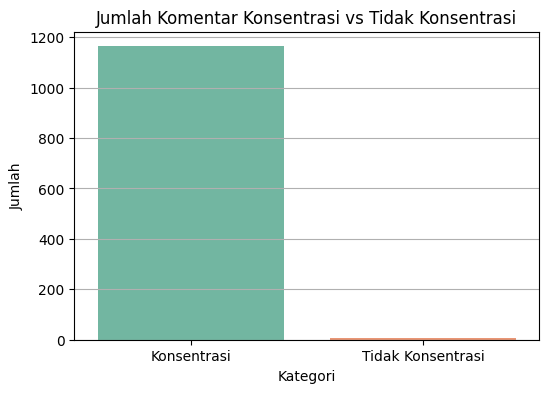


=== Kata Teratas - Konsentrasi ===


,Kata,Frekuensi
0,sebut,91
1,bang,77
2,nya,64
3,di,58
4,kak,56
5,jg,51
6,serta,50
7,kerenkeren,50
8,dapat,49
9,ingin,42



=== Kata Teratas - Tidak Konsentrasi ===


,Kata,Frekuensi
0,stecu,2
1,sebut,2
2,eyjzzwfyy2hfc2lkijoiywe1zmm0mzezzwy2zgzmzgrhnzvkn2qwogi0ndm4zweilcjxdwvyesi6ikplbwugsmfyywkilcjzzwfyy2hfdhlwzsi6ilnlyxjjacisinnlcxvlbmnlx2lkijoymde1mdi5njusinbhz2vfbnvtymvyijoxlcjmawx0zxjfdhlwzsi6ilnlyxjjacisimvudf9pzci6mtk1nzqxotqwntmyodezlcjwb3npdglvbii6mywicmvzdwx0x3r5cguiojy5fq,2
3,elo,2
4,eyjzzwfyy2hfc2lkijoiywe1zmm0mzezzwy2zgzmzgrhnzvkn2qwogi0ndm4zweilcjxdwvyesi6ikplbwugsmfyywkilcjzzwfyy2hfdhlwzsi6ilnlyxjjacisinnlcxvlbmnlx2lkijoymda2ntqwoty3lcjwywdlx251bwjlcii6mswizmlsdgvyx3r5cguioijtzwfyy2gilcjlbnrfawqiojexmtkzndy3mzq3ntc5otusinbvc2l0aw9uijozlcjyzxn1bhrfdhlwzsi6njl9,2
5,kamu,1
6,ngedengerinnya,1
7,ya,1
8,talitharty,1
9,apa,1


<ipython-input-16-3481208622>:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_konsentrasi, y='Kata', x='Frekuensi', palette='Blues_r')
<ipython-input-16-3481208622>:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_tdk_konsentrasi, y='Kata', x='Frekuensi', palette='Oranges_r')
<ipython-input-16-3481208622>:60: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-16-3481208622>:60: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-16-3481208622>:60: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough 

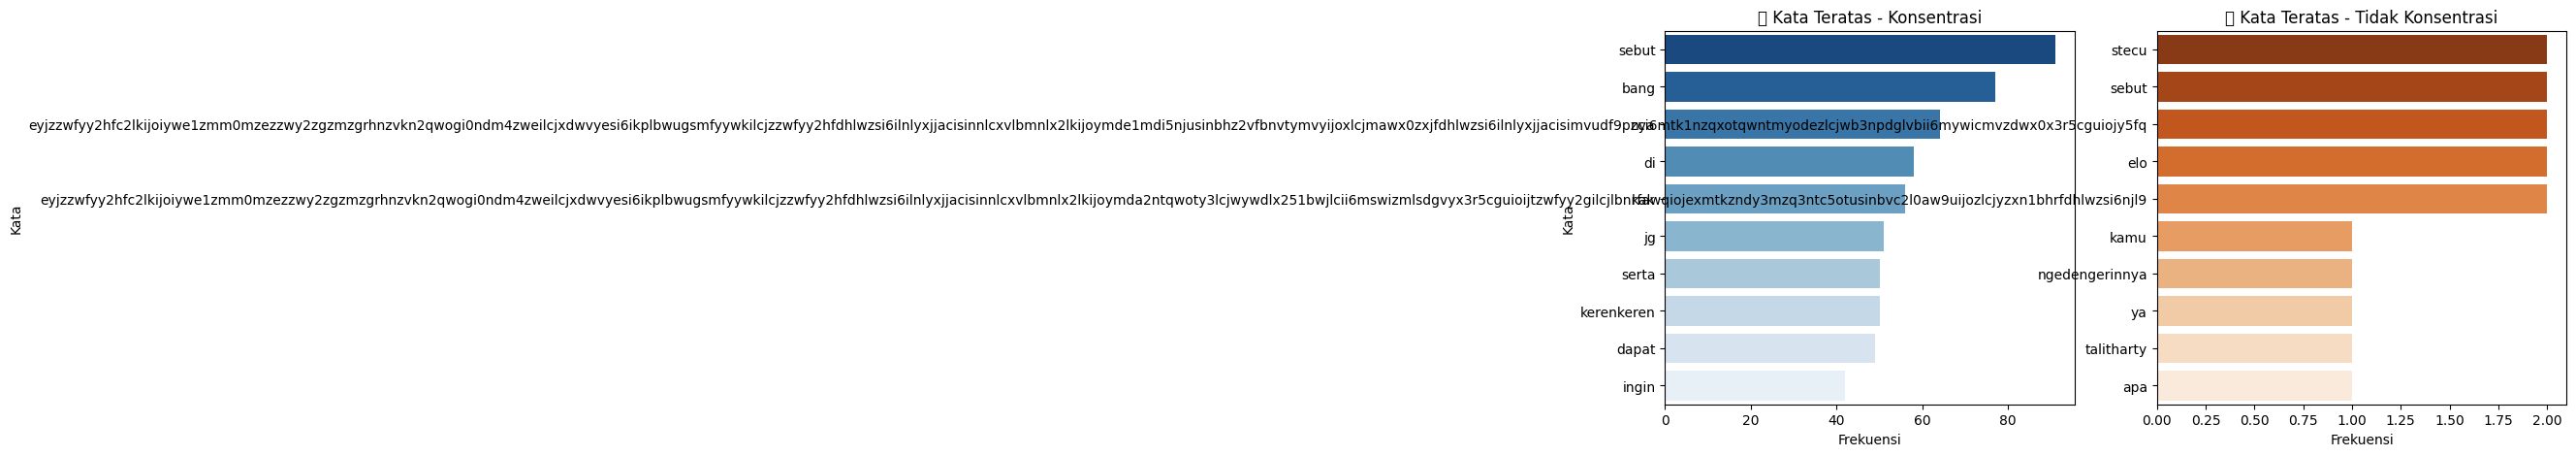

In [16]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Hitung jumlah kategori
jumlah_kategori = df_all['kategori'].value_counts()
print("=== Jumlah Data per Kategori ===")
print(jumlah_kategori)

# 2. Tampilkan diagram jumlah kategori
plt.figure(figsize=(6,4))
sns.countplot(data=df_all, x='kategori', palette='Set2')
plt.title("Jumlah Komentar Konsentrasi vs Tidak Konsentrasi")
plt.xlabel("Kategori")
plt.ylabel("Jumlah")
plt.grid(axis='y')
plt.show()

# 3. Tokenisasi komentar_nlp → pisahkan per kategori
df_all['tokens'] = df_all['komentar_nlp'].astype(str).str.split()

# Ambil token per kategori
tokens_konsentrasi = df_all[df_all['kategori'] == 'Konsentrasi']['tokens'].sum()
tokens_tdk_konsentrasi = df_all[df_all['kategori'] == 'Tidak Konsentrasi']['tokens'].sum()

# Hitung kata paling sering muncul
# Check if the token list is not empty before using Counter
top_konsentrasi = Counter(tokens_konsentrasi).most_common(10) if tokens_konsentrasi else []
top_tdk_konsentrasi = Counter(tokens_tdk_konsentrasi).most_common(10) if tokens_tdk_konsentrasi else []

# Buat dataframe
df_konsentrasi = pd.DataFrame(top_konsentrasi, columns=['Kata', 'Frekuensi'])
df_tdk_konsentrasi = pd.DataFrame(top_tdk_konsentrasi, columns=['Kata', 'Frekuensi'])

# 4. Tampilkan tabel
print("\n=== Kata Teratas - Konsentrasi ===")
display(df_konsentrasi)

print("\n=== Kata Teratas - Tidak Konsentrasi ===")
display(df_tdk_konsentrasi)

# 5. Diagram kata teratas
plt.figure(figsize=(12, 5))

# Konsentrasi
plt.subplot(1, 2, 1)
sns.barplot(data=df_konsentrasi, y='Kata', x='Frekuensi', palette='Blues_r')
plt.title("🔵 Kata Teratas - Konsentrasi")
plt.xlabel("Frekuensi")
plt.ylabel("Kata")

# Tidak Konsentrasi
plt.subplot(1, 2, 2)
sns.barplot(data=df_tdk_konsentrasi, y='Kata', x='Frekuensi', palette='Oranges_r')
plt.title("🟠 Kata Teratas - Tidak Konsentrasi")
plt.xlabel("Frekuensi")
plt.ylabel("Kata")

plt.tight_layout()
plt.show()

***Pelatihan model***

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.8114 - loss: 0.4352 - val_accuracy: 1.0000 - val_loss: 1.1544e-04
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.9942 - loss: 0.0637 - val_accuracy: 1.0000 - val_loss: 0.0054
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.9933 - loss: 0.0470 - val_accuracy: 1.0000 - val_loss: 0.0042
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.9955 - loss: 0.0318 - val_accuracy: 1.0000 - val_loss: 0.0052
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.9942 - loss: 0.0447 - val_accuracy: 1.0000 - val_loss: 0.0057
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.9940 - loss: 0.0381 - val_accuracy: 1.0000 - val_loss: 0.0059
Epoch 7/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.9939 - loss: 0.0410 - val_accuracy: 1.0000 - val_loss: 0.0062
Epoch 8/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.9887 - loss: 0.0538 - val_accuracy: 1.0000

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


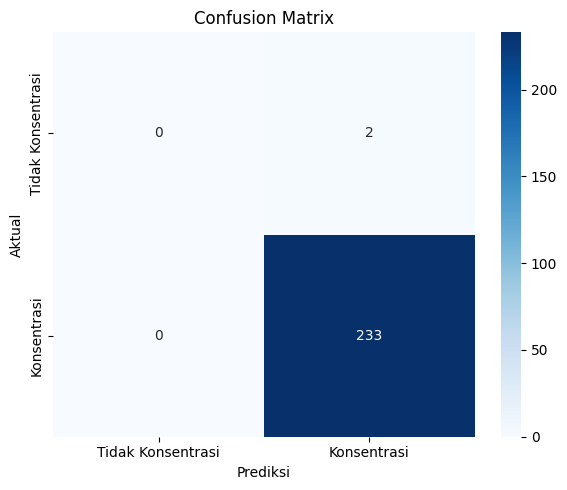

In [18]:
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load data
df = pd.read_csv('preprocessIG.csv')
df = df.dropna(subset=['text', 'prediksi_konsentrasi'])

# 2. Label dan data teks
texts = df['text'].values
labels = df['prediksi_konsentrasi'].values

# 3. Tokenisasi teks
max_words = 10000  # jumlah maximal kata
max_len = 100      # panjang sequence (bisa disesuaikan)

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
X = pad_sequences(sequences, maxlen=max_len)

# 4. Label untuk binary classification (0 dan 1)
y = labels

# 5. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Bangun model CNN
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model.add(Conv1D(filters=128, kernel_size=5, activation='relu'))
model.add(GlobalMaxPooling1D())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))  # output 1 node dengan sigmoid untuk binary classification

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

# 7. Latih model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    class_weight={0: 1, 1: 1}  # Bisa diatur sesuai kebutuhan
)

# 8. Evaluasi
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("\n=== Classification Report ===")

unique_labels_test = np.unique(y_test)

if len(unique_labels_test) < 2:
    print("Note: Only one class is present in the test set due to limited training data. Classification report is not applicable.")
    # Manually calculate and print accuracy if only one class is present
    print(f"✅ Akurasi: {accuracy_score(y_test, y_pred) * 100:.2f} %")
else:
    target_names = ['Tidak Konsentrasi', 'Konsentrasi']
    # Filter target_names based on unique labels in y_test
    filtered_target_names = [name for i, name in enumerate(target_names) if i in unique_labels_test]
    print(classification_report(y_test, y_pred, target_names=filtered_target_names))
    print("\n✅ Akurasi:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")

# Ensure confusion matrix labels match the unique labels in y_test
cm = confusion_matrix(y_test, y_pred, labels=unique_labels_test)
labels_cm = [name for i, name in enumerate(['Tidak Konsentrasi', 'Konsentrasi']) if i in unique_labels_test]


plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_cm, yticklabels=labels_cm)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

***Kesimpulan***

In [20]:
# === Analisis Konsentrasi Otomatis ===
total_konsentrasi = jumlah_kategori.get('Konsentrasi', 0)
total_tidak_konsentrasi = jumlah_kategori.get('Tidak Konsentrasi', 0)
total_data = total_konsentrasi + total_tidak_konsentrasi

persen_konsentrasi = (total_konsentrasi / total_data) * 100 if total_data else 0
persen_tidak = (total_tidak_konsentrasi / total_data) * 100 if total_data else 0

print(f"\n📊 Total Data: {total_data}")
print(f"✅ Konsentrasi: {total_konsentrasi} data ({persen_konsentrasi:.2f}%)")
print(f"❌ Tidak Konsentrasi: {total_tidak_konsentrasi} data ({persen_tidak:.2f}%)")
print("\n--- KESIMPULAN ---")

if persen_konsentrasi > 80:
    print("✅ Mayoritas mahasiswa menunjukkan konsentrasi saat belajar pemrograman melalui media Instagram.")
    print("💡 Hal ini menunjukkan bahwa media Instagram efektif dan menunjang dalam meningkatkan konsentrasi belajar mahasiswa.")
elif persen_konsentrasi > 50:
    print("🔍 Sebagian besar mahasiswa cukup konsentrasi belajar melalui media Instagram.")
    print("💡 Media ini cukup membantu namun perlu evaluasi untuk menjangkau semua mahasiswa.")
else:
    print("⚠️ Mayoritas mahasiswa kurang konsentrasi saat belajar menggunakan media Instagram.")
    print("❗ Disarankan mencari media atau metode pembelajaran lain yang lebih efektif.")



📊 Total Data: 1171
✅ Konsentrasi: 1163 data (99.32%)
❌ Tidak Konsentrasi: 8 data (0.68%)

--- KESIMPULAN ---
✅ Mayoritas mahasiswa menunjukkan konsentrasi saat belajar pemrograman melalui media Instagram.
💡 Hal ini menunjukkan bahwa media Instagram efektif dan menunjang dalam meningkatkan konsentrasi belajar mahasiswa.
